# 15 — LSA / Latent Semantic Analysis (estrattivo, implementazione custom)

Implementa il metodo della **§3.5** del [documento-guida](../Tecniche_MDS_non_LLM_MultiNews.md)
("LSA — Latent Semantic Analysis"): si scompone la matrice **termine × frase** con la **SVD**
(*Singular Value Decomposition*), si tengono le poche dimensioni latenti più forti — i "concetti"
del cluster — e si scelgono le frasi che **rappresentano meglio** quei concetti.

L'intuizione è la stessa dell'algebra lineare di base: la SVD riscrive la matrice come somma di
poche "direzioni" ordinate per importanza. Le prime direzioni catturano i temi ricorrenti del
cluster, le ultime il rumore (parole occasionali, refusi). Ragionare sui **concetti** invece che
sulle parole permette di riconoscere come affini due frasi che dicono la stessa cosa con parole
diverse — il classico esempio di *sinonimia* che la sola sovrapposizione lessicale (TF-IDF puro,
notebook 11) non coglie.

Come i notebook 11 e 13, la pipeline è scritta **da zero con scikit-learn + numpy**, senza librerie
plug-and-play (`sumy` avrebbe dato solo la variante base, vedi sotto):

1. **Segmentazione** in frasi con `psr.summarization` (la **stessa** di
   TextRank / LexRank / firstk_psr / centroid_mmr / lda): il pool di candidati è identico agli
   altri estrattivi, quindi i punteggi sono confrontabili.
2. **Matrice frase × termine** con `TfidfVectorizer` — la SVD lavora sui pesi, non sui conteggi
   grezzi (a differenza di LDA, notebook 13).
3. **SVD troncata** a `K_LATENTE` dimensioni (`sklearn.TruncatedSVD`): ogni frase diventa un
   vettore corto `z` nello **spazio dei concetti**.
4. **Punteggio di salienza** = **lunghezza** del vettore della frase nello spazio latente,
   `‖z‖ = √(Σₖ σₖ² · vₖᵢ²)` — è la formula di Steinberger & Ježek: una frase conta se porta
   *molto* contenuto sui concetti *importanti* (σₖ grande).
5. Le frasi scelte sono **riordinate in ordine di documento** e concatenate.

## Due varianti: con e senza anti-ridondanza (confronto)

Il documento-guida segnala un punto preciso: la variante **multi-documento di Steinberger**
aggiorna *iterativamente* la matrice approssimata per **non riselezionare contenuto già coperto**,
meccanismo **assente** nell'implementazione standard di `sumy` — ed è indicato come "possibile
spunto di approfondimento". Qui lo si implementa, e lo si misura, generando **due slug** dalla
stessa esecuzione:

- **`lsa`** — selezione *top-k* pura: si prendono le `N_SENTENCES` frasi con `‖z‖` più alto. È
  quello che fa `sumy.LsaSummarizer` (impostazione Gong & Liu / Steinberger senza update).
- **`lsa_steinberger`** — selezione **greedy con deflazione**: dopo aver scelto una frase, si
  **sottrae** dai vettori delle frasi rimanenti la componente lungo la direzione appena
  selezionata (`z ← z − (z·û)û`) e si ricalcolano i punteggi. Il contenuto già coperto smette di
  valere: le frasi che ripetono la prima crollano di punteggio, quelle che aggiungono un concetto
  nuovo salgono.

Le due varianti differiscono **solo** per la regola di selezione (stessa segmentazione, stessa
matrice, stessa SVD): il confronto isola l'effetto dell'anti-ridondanza, che è esattamente il
problema centrale della summarization **multi-documento** (le fonti si ripetono tra loro).

## Inquadramento nella lezione del Master

Copertura **piena**: la lezione dedica a LSA le slide 60-62, riferite proprio alla *LSA-based
Multi-Document Summarization* di Steinberger. Pro citati a lezione: **semplicità, scalabilità e
indipendenza dalla lingua** (nessun modello addestrato, nessuna risorsa linguistica oltre alle
stop-word). Unico contro citato: LSA **considera solo relazioni a livello di parola**, non
co-occorrenze tra più termini — è precisamente il limite che motiva i metodi *itemset-based*
(§4.1 del documento-guida). Da tenere presente anche che l'ambiguità di segno della SVD rende i
concetti meno "leggibili" dei topic di LDA (vedi Passo 3).

Tre ambiti (`SCOPE`): `sample` (campione condiviso, default), `test` (intera split test pulita,
5.610 righe — impostato via `SUMM_SCOPE` da `scripts/run_benchmark_test.py`) e `full` (intero
`complete.tab` in streaming). Gira su **CPU**, nessuna GPU necessaria. Riassunti salvati
incrementalmente con **ripresa**; metriche ricalcolabili dai soli file salvati.

In [1]:
# Installa le dipendenze se mancanti (per esempio su Google Colab)
try:
    import pyAutoSummarizer  # noqa: F401  (segmentazione delle frasi + valutatore condiviso)
except ImportError:
    %pip install pyAutoSummarizer sentencepiece

try:
    import sklearn  # noqa: F401  (TfidfVectorizer + TruncatedSVD)
except ImportError:
    %pip install scikit-learn

try:
    import pandas  # noqa: F401  (anteprime tabellari della sezione di spiegazione)
    import matplotlib  # noqa: F401  (grafici della sezione di spiegazione)
except ImportError:
    %pip install pandas matplotlib

In [2]:
# --- Configurazione ---------------------------------------------------------
import os

import summ_utils as su

# 'sample' (default) | 'test' (split test pulita) | 'full' (intero complete.tab);
# scripts/run_benchmark_test.py imposta SUMM_SCOPE='test'
SCOPE       = os.environ.get('SUMM_SCOPE', 'sample')
N_SAMPLES   = 100        # deve combaciare con il campione creato dal notebook 00
SEED        = 42
# es. 3 per uno smoke test rapido; None = tutti; SUMM_LIMIT usato da run_benchmark_test.py
LIMIT       = int(os.environ['SUMM_LIMIT']) if 'SUMM_LIMIT' in os.environ else None
N_SENTENCES = 11         # frasi selezionate per riassunto (mediana del corpus, come 01/02/11/13)
# Dimensioni latenti tenute dalla SVD. Il default = N_SENTENCES segue la convenzione di
# Gong & Liu (una dimensione per frase estratta) ed e' anche un VINCOLO della variante con
# deflazione: dopo K_LATENTE sottrazioni lo spazio residuo si annulla, quindi servono almeno
# tante dimensioni quante sono le frasi da scegliere. Viene comunque cappata al rango della
# matrice del singolo cluster.
K_LATENTE   = N_SENTENCES
STOP_WORDS  = ['en']     # solo per la segmentazione con psr; l'output resta il testo originale

# Le due varianti: stessa SVD, regola di selezione diversa
METODO_BASE = 'lsa'              # top-k per ||z|| (equivalente a sumy.LsaSummarizer)
METODO_STEIN = 'lsa_steinberger'  # greedy con deflazione (anti-ridondanza, variante MDS)
METODI      = [METODO_BASE, METODO_STEIN]

BASE   = su.trova_base_dir()
P      = su.percorsi_standard(BASE)
SAMPLE_PATH = P['sample_dir'] / f'sample_{N_SAMPLES}_seed{SEED}.tsv'


def esempi_scope():
    """Iterabile degli esempi dell'ambito selezionato (riusato anche dalla valutazione)."""
    if SCOPE == 'sample':
        return su.carica_campione(SAMPLE_PATH)
    if SCOPE == 'test':
        return su.itera_split(P['complete_tab'], 'test')
    if SCOPE == 'full':
        return su.itera_complete_tab(P['complete_tab'])
    raise ValueError(f'SCOPE non valido: {SCOPE!r}')


print(f'Ambito (SCOPE)     : {SCOPE}')
print(f'Frasi/riassunto    : {N_SENTENCES}')
print(f'Dimensioni latenti : {K_LATENTE} (cappate al rango di ogni cluster)')
print(f'Varianti           : {METODI}')

Ambito (SCOPE)     : test
Frasi/riassunto    : 11
Dimensioni latenti : 11 (cappate al rango di ogni cluster)
Varianti           : ['lsa', 'lsa_steinberger']


## Generazione dei riassunti

Per ogni documento (separatore `` ||||| `` sostituito con newline dal ciclo condiviso) si istanzia
`psr.summarization` e se ne leggono le frasi originali (`s.original`, in ordine di documento). Le
frasi formano il pool su cui gira la pipeline **custom**:

1. **TF-IDF** → matrice frase × termine (stop-word inglesi rimosse).
2. **`TruncatedSVD`** con `k = min(K_LATENTE, rango)` → matrice `Z` frase × concetto, con le
   colonne **già scalate per i valori singolari σ** (`TruncatedSVD.fit_transform` restituisce
   `U·Σ`, cioè esattamente i vettori-frase nello spazio latente di Steinberger).
3. **Salienza** di ogni frase = `‖z‖₂`, la sua lunghezza nello spazio dei concetti.
4. **Selezione**, nelle due varianti:
   - `lsa` — le `N_SENTENCES` frasi con `‖z‖` più alto;
   - `lsa_steinberger` — greedy: si sceglie la frase più saliente, si **deflaziona** lo spazio
     (`z ← z − (z·û)û` per tutte le altre, con `û` direzione della frase scelta), si ricalcolano
     le lunghezze, si ripete.
5. Frasi selezionate **riordinate in ordine di documento** e concatenate.

Le due varianti si generano in sequenza in file separati (`results/summaries/{metodo}_{scope}.tsv`),
ciascuna con **ripresa** automatica. Casi limite: se le frasi sono ≤ `N_SENTENCES` si restituiscono
tutte; se il `TfidfVectorizer` produce un vocabolario vuoto (testi minimi) si ricade sulle prime
`N_SENTENCES` frasi; se durante la deflazione lo spazio residuo si azzera si completa il budget con
le frasi migliori per salienza *originale*.

In [3]:
import numpy as np
from pyAutoSummarizer.base import psr
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

EPS = 1e-12   # soglia sotto la quale un vettore latente e' considerato esaurito


def segmenta(documento):
    """Frasi del cluster con la segmentazione di psr.summarization (come TextRank/LexRank).

    `s.original` e' la lista delle frasi originali in ordine di documento. Si scartano
    le stringhe vuote.
    """
    s = psr.summarization(documento, stop_words=STOP_WORDS)
    return [f.strip() for f in getattr(s, 'original', []) if f and f.strip()]


def seleziona_topk(Z, n_sentences):
    """Variante `lsa`: le n_sentences frasi con vettore latente piu' lungo.

    E' la regola di Gong & Liu / Steinberger senza update, la stessa di sumy.LsaSummarizer:
    nessuna memoria di cosa e' gia' stato scelto.
    """
    salienza = np.linalg.norm(Z, axis=1)
    return [int(i) for i in np.argsort(-salienza)[:n_sentences]]


def seleziona_deflazione(Z, n_sentences):
    """Variante `lsa_steinberger`: greedy con aggiornamento della matrice approssimata.

    Ad ogni passo si prende la frase con vettore residuo piu' lungo e si sottrae la sua
    direzione da tutti i vettori rimanenti (proiezione ortogonale). Il contenuto gia'
    coperto sparisce dal residuo, quindi una frase che ripete la precedente vale ~0 e non
    viene riscelta: e' l'anti-ridondanza della variante multi-documento di Steinberger,
    assente in sumy.

    Ritorna (scelti, storia) dove `storia[t]` sono le lunghezze residue di TUTTE le frasi
    prima della t-esima scelta (serve alle figure della sezione di spiegazione).
    """
    R = np.array(Z, dtype=float, copy=True)     # matrice residua, si consuma passo dopo passo
    scelti, storia = [], []
    for _ in range(min(n_sentences, len(R))):
        lunghezze = np.linalg.norm(R, axis=1)
        storia.append(lunghezze.copy())
        lunghezze[scelti] = -1.0                # una frase gia' scelta non torna candidata
        i = int(np.argmax(lunghezze))
        if lunghezze[i] <= EPS:                 # spazio residuo esaurito: niente da aggiungere
            break
        scelti.append(i)
        u = R[i] / np.linalg.norm(R[i])         # direzione appena "spesa"
        R -= np.outer(R @ u, u)                 # z_j <- z_j - (z_j . u) u, per ogni frase
    # se la deflazione si e' fermata presto, completo con la salienza ORIGINALE
    if len(scelti) < min(n_sentences, len(Z)):
        for i in np.argsort(-np.linalg.norm(Z, axis=1)):
            if int(i) not in scelti:
                scelti.append(int(i))
            if len(scelti) >= min(n_sentences, len(Z)):
                break
    return scelti, storia


SELETTORI = {METODO_BASE: lambda Z, n: seleziona_topk(Z, n),
             METODO_STEIN: lambda Z, n: seleziona_deflazione(Z, n)[0]}


def analizza_lsa(frasi, k=None, n_sentences=None):
    """SVD del cluster + selezione con ENTRAMBE le varianti.

    Ritorna gli artefatti intermedi, usati sia in produzione sia dalle figure:
    `X` (TF-IDF frase x termine), `Z` (frase x concetto, gia' scalata per sigma),
    `salienza` (||z|| per frase), `sigma` (valori singolari), `componenti`
    (concetto x termine), `vocab`, `k`, `scelti` ({metodo: indici}) e `storia`
    (lunghezze residue passo per passo della variante con deflazione).
    Solleva ValueError se il vocabolario TF-IDF e' vuoto (testi minimi).
    """
    k = K_LATENTE if k is None else k
    n_sentences = N_SENTENCES if n_sentences is None else n_sentences
    vettorizzatore = TfidfVectorizer(stop_words='english')
    X = vettorizzatore.fit_transform(frasi)     # ValueError se il vocabolario e' vuoto
    # TruncatedSVD richiede n_components < n_features e non puo' superare il rango
    k = max(1, min(k, min(X.shape) - 1))
    svd = TruncatedSVD(n_components=k, random_state=SEED)
    Z = svd.fit_transform(X)                    # (n_frasi, k) = U * Sigma
    scelti_stein, storia = seleziona_deflazione(Z, n_sentences)
    return {'X': X, 'Z': Z, 'salienza': np.linalg.norm(Z, axis=1),
            'sigma': svd.singular_values_, 'componenti': svd.components_,
            'varianza': svd.explained_variance_ratio_,
            'vocab': vettorizzatore.get_feature_names_out(),
            'k': k, 'storia': storia,
            'scelti': {METODO_BASE: seleziona_topk(Z, n_sentences),
                       METODO_STEIN: scelti_stein}}


def make_genera(metodo):
    """Crea genera(documento) per una delle due varianti di selezione."""
    seleziona = SELETTORI[metodo]

    def genera(documento):
        frasi = segmenta(documento)
        if len(frasi) <= N_SENTENCES:
            return ' '.join(frasi)
        try:
            X = TfidfVectorizer(stop_words='english').fit_transform(frasi)
            k = max(1, min(K_LATENTE, min(X.shape) - 1))
            Z = TruncatedSVD(n_components=k, random_state=SEED).fit_transform(X)
            indici = sorted(seleziona(Z, N_SENTENCES))
        except ValueError:            # vocabolario TF-IDF vuoto su testi minimi
            indici = range(N_SENTENCES)
        return ' '.join(frasi[i] for i in indici)
    return genera


for metodo in METODI:
    out_path = P['summaries_dir'] / f'{metodo}_{SCOPE}.tsv'
    scrittore = su.ScrittoreRiassunti(out_path)
    print(f'== {metodo} -> {out_path.name} ==')
    su.ciclo_summarization(esempi_scope(), scrittore, make_genera(metodo),
                           limit=LIMIT, etichetta=f'{metodo} ')
    scrittore.chiudi()

C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.6.0)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


== lsa -> lsa_test.tsv ==


lsa [1] media 8.1 s/esempio (saltati 10 gia' fatti)
lsa [2] media 4.0 s/esempio (saltati 10 gia' fatti)
lsa [3] media 2.7 s/esempio (saltati 10 gia' fatti)
lsa [10] media 0.8 s/esempio (saltati 10 gia' fatti)
lsa [20] media 0.4 s/esempio (saltati 10 gia' fatti)


lsa [30] media 0.3 s/esempio (saltati 10 gia' fatti)
  ERRORE su row_id=50531: IndexError('list assignment index out of range')
lsa [40] media 0.2 s/esempio (saltati 10 gia' fatti)


...

lsa_steinberger [5510] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger [5520] media 0.0 s/esempio (saltati 10 gia' fatti)


lsa_steinberger [5530] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger [5540] media 0.0 s/esempio (saltati 10 gia' fatti)


lsa_steinberger [5550] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger [5560] media 0.0 s/esempio (saltati 10 gia' fatti)


lsa_steinberger [5570] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger [5580] media 0.0 s/esempio (saltati 10 gia' fatti)


lsa_steinberger [5590] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger [5600] media 0.0 s/esempio (saltati 10 gia' fatti)
lsa_steinberger Completato: 5600 nuovi, 10 saltati, 22 errori, 104 s totali


## Come funziona, passo per passo

Questa sezione **apre la scatola nera** della pipeline su un singolo documento-esempio (parametro
`RIGA_DEMO`) e mostra, con **output e grafici intermedi**, come si passa dagli articoli grezzi alle
frasi del riassunto. È puramente illustrativa: non tocca i riassunti/metriche prodotti sopra
(`analizza_lsa` è la **stessa** funzione usata in produzione).

### La SVD in una riga

Chiamiamo `A` la matrice **frase × termine**. La SVD la riscrive come

> `A = U · Σ · Vᵀ`

- **`Σ`** è diagonale e contiene i **valori singolari** `σ₁ ≥ σ₂ ≥ …`: quanta "energia" della
  matrice sta in ciascuna dimensione latente. Sono ordinati: le prime dimensioni sono i concetti
  dominanti del cluster, le ultime rumore.
- **`Vᵀ`** (`svd.components_`) dice **di quali parole è fatto ogni concetto** — l'analogo della β
  di LDA (notebook 13).
- **`U · Σ`** (`svd.fit_transform(A)`, la nostra matrice `Z`) dice **quanto ogni frase parla di
  ogni concetto**, già pesato per l'importanza del concetto.

**Troncare** a `k` dimensioni (`TruncatedSVD`) significa tenere solo i primi `k` concetti: è al
tempo stesso una compressione e un **filtro anti-rumore**. È il passaggio che dà a LSA la sua
proprietà interessante — due frasi che usano parole diverse per dire la stessa cosa finiscono
vicine nello spazio dei concetti.

### Perché il TF-IDF e non i conteggi

Al contrario di LDA (notebook 13), che è un modello probabilistico definito su **occorrenze
intere** e quindi vuole `CountVectorizer`, la SVD è una pura fattorizzazione di matrici: accetta
qualsiasi pesatura, e il TF-IDF è quella classica in LSA perché smorza le parole diffuse ovunque e
valorizza quelle discriminanti.

### Un'avvertenza sui segni

La SVD è definita **a meno del segno**: `(u, v)` e `(−u, −v)` danno la stessa `A`. Quindi il segno
dei carichi di un concetto non ha significato — nelle figure si guarda il **valore assoluto**. È
una differenza pratica rispetto a LDA, dove i topic sono distribuzioni di probabilità (tutte
positive) e quindi più direttamente leggibili.

*Nota sui colori:* l'identità dei concetti è data da **posizione ed etichette `C0…Ck`**; il colore
la ribadisce ma non è mai l'unico canale.

In [4]:
# --- Setup della dimostrazione (Passo 1: segmentazione) ---------------------
import matplotlib.pyplot as plt

RIGA_DEMO    = 0        # indice del documento nel campione da ispezionare
N_PAROLE_TOP = 8        # parole per concetto nella figura dei carichi
N_CONCETTI_FIG = 5      # quanti concetti mostrare nelle figure (i primi, i piu' forti)
SALVA_FIGURE = True     # salva anche i PNG in results/figures/lsa/
FIG_DIR      = P['metrics_dir'].parent / 'figures' / 'lsa'

# Palette coerente con i notebook 05/11/13
INK, MUTED, GRID, SURFACE, ACCENTO = '#0b0b0b', '#898781', '#e1e0d9', '#fcfcfb', '#0d9488'
CONCEPT_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4',
                  '#008300', '#4a3aa7', '#e34948']
plt.rcParams.update({'font.family': 'sans-serif', 'text.color': INK,
                     'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def col_concetto(c):
    return CONCEPT_COLORS[int(c) % len(CONCEPT_COLORS)]


def _salva(fig, nome):
    if SALVA_FIGURE:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / nome, dpi=150, bbox_inches='tight', facecolor=SURFACE)
        print(f'  figura salvata: {FIG_DIR / nome}')


# Documento-esempio -> frasi. Se e' troppo corto per una demo significativa (<= N_SENTENCES
# frasi, nessuna vera selezione), si avanza al primo documento piu' lungo del campione.
_campione = su.carica_campione(SAMPLE_PATH)
esempio = _campione[RIGA_DEMO]
frasi = segmenta(su.prepara_documento(esempio['document']))
if len(frasi) <= N_SENTENCES:
    for e in _campione[RIGA_DEMO:] + _campione[:RIGA_DEMO]:
        f = segmenta(su.prepara_documento(e['document']))
        if len(f) > N_SENTENCES:
            esempio, frasi = e, f
            break
rid = esempio['row_id']
articoli = [a for a in esempio['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
print('PASSO 1 - Segmentazione')
print(f"Documento row_id={rid} (split={esempio['split']}): {len(articoli)} articoli -> "
      f'{len(frasi)} frasi nel pool')
print('Prime 3 frasi del pool:')
for i in range(min(3, len(frasi))):
    print(f'  [{i}] {frasi[i][:120]}')

PASSO 1 - Segmentazione
Documento row_id=425 (split=train): 3 articoli -> 71 frasi nel pool
Prime 3 frasi del pool:
  [0] Campaign mailer sent by GOP state Senate candidate Ed Charamut
  [1] The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that depicts thei
  [2] There’s also a lead tagline on the other side: “Matt Lesser will take everything you worked for.” It was mailed out to h


### Passo 2 — Dalla parola al peso (matrice TF-IDF)

`TfidfVectorizer` costruisce la matrice **frase × termine**: ogni riga è una frase, ogni colonna
una parola del vocabolario, il valore è il peso TF-IDF (alto se la parola è frequente *in quella
frase* ma rara *nel cluster*). È la matrice `A` che verrà fattorizzata. Sotto: dimensioni,
sparsità e un'anteprima dei pesi per le prime frasi sui termini più "pesanti" del cluster.

PASSO 2 - Matrice TF-IDF
71 frasi x 562 termini (sparsa, 2.4% celle non nulle)

Anteprima pesi TF-IDF (prime frasi x 12 termini di peso maggiore):


,lesser,mailer,said,jewish,republican,candidate,anti,state,campaign,party,charamut,rep
frase 0,0.00,0.26,0.00,0.0,0.00,0.29,0.00,0.3,0.31,0.00,0.33,0.00
frase 1,0.10,0.21,0.00,0.2,0.11,0.12,0.11,0.0,0.25,0.13,0.00,0.00
frase 2,0.28,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
frase 3,0.00,0.00,0.22,0.0,0.23,0.00,0.00,0.0,0.00,0.00,0.28,0.32
frase 4,1.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
frase 5,0.00,0.13,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00


  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\tfidf_row425.png


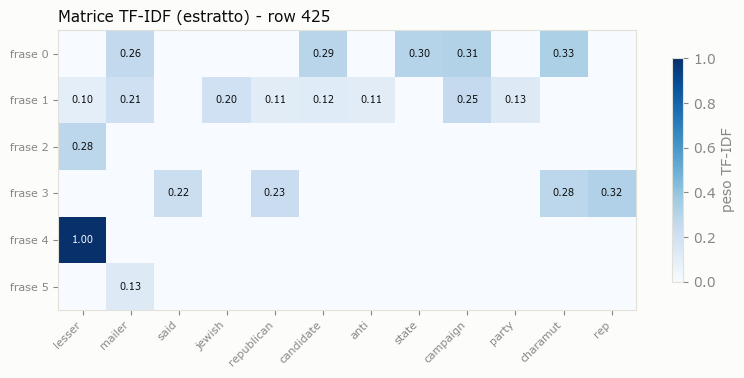

In [5]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
A = tfidf.fit_transform(frasi)
vocab = tfidf.get_feature_names_out()
densita = A.nnz / (A.shape[0] * A.shape[1])
print('PASSO 2 - Matrice TF-IDF')
print(f'{A.shape[0]} frasi x {len(vocab)} termini (sparsa, {densita:.1%} celle non nulle)')

# Termini con peso complessivo maggiore + anteprima
peso_termini = np.asarray(A.sum(axis=0)).ravel()
top_termini = np.argsort(-peso_termini)[:12]
nomi_top = [vocab[j] for j in top_termini]
n_ant = min(6, A.shape[0])
anteprima = pd.DataFrame(A[:n_ant][:, top_termini].toarray().round(2), columns=nomi_top,
                         index=[f'frase {i}' for i in range(n_ant)])
print()
print("Anteprima pesi TF-IDF (prime frasi x 12 termini di peso maggiore):")
display(anteprima)

fig, ax = plt.subplots(figsize=(8, 0.38 * n_ant + 1.6), facecolor=SURFACE)
im = ax.imshow(anteprima.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(nomi_top)))
ax.set_xticklabels(nomi_top, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n_ant))
ax.set_yticklabels(anteprima.index, fontsize=8)
for (yy, xx), v in np.ndenumerate(anteprima.values):
    if v:
        ax.text(xx, yy, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color=INK if v < anteprima.values.max() * 0.6 else SURFACE)
fig.colorbar(im, ax=ax, shrink=0.8, label='peso TF-IDF')
ax.set_title(f'Matrice TF-IDF (estratto) - row {rid}', color=INK, loc='left', fontsize=11)
plt.tight_layout()
_salva(fig, f'tfidf_row{rid}.png')
plt.show()

### Passo 3 — I concetti latenti: σ, `Vᵀ` e `Z`

Si applica `TruncatedSVD` alla matrice TF-IDF. Escono le tre cose che servono:

- **σ (valori singolari)** — prima figura, *scree plot*: mostra quanta energia porta ogni
  dimensione e quanto in fretta la curva "scende". Il gomito dice quanti concetti servono davvero;
  la quota di varianza spiegata dai `k` tenuti quantifica quanto della matrice originale stiamo
  conservando.
- **`Vᵀ` (`svd.components_`)** — seconda figura: le parole con **carico assoluto** maggiore per
  ogni concetto, cioè di che cosa parla quel concetto. (Segno ignorato, vedi avvertenza sopra.)
- **`Z = U·Σ`** — terza figura, heatmap frase × concetto: quanto ogni frase parla di ogni concetto.
  Righe "accese" su una sola colonna = frasi monotematiche; righe scure = frasi poco informative.
  La lunghezza di ogni riga è il punteggio di salienza del Passo 4.

PASSO 3 - SVD troncata a k=11 concetti; matrice Z (71, 11) (frase x concetto)
Varianza spiegata dai 11 concetti tenuti: 26.5%
Parole con carico maggiore per concetto (|Vt|):
  C0 (sigma=1.96): mailer, lesser, state, candidate, campaign, charamut, sent, jewish
  C1 (sigma=1.56): anti, lesser, semitic, jewish, offensive, tropes, classic, recognized
  C2 (sigma=1.46): lesser, altered, rep, republican, ed, greenspan, sent, state
  C3 (sigma=1.37): justified, said, approved, party, ad, altered, greenspan, did
  C4 (sigma=1.32): party, justified, statement, altered, approved, opportunity, context, discuss
  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\scree_row425.png


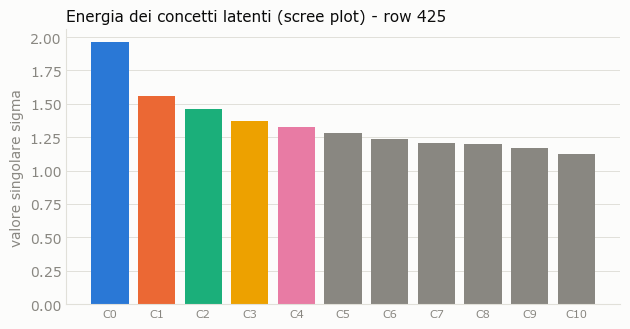

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\parole_concetto_row425.png


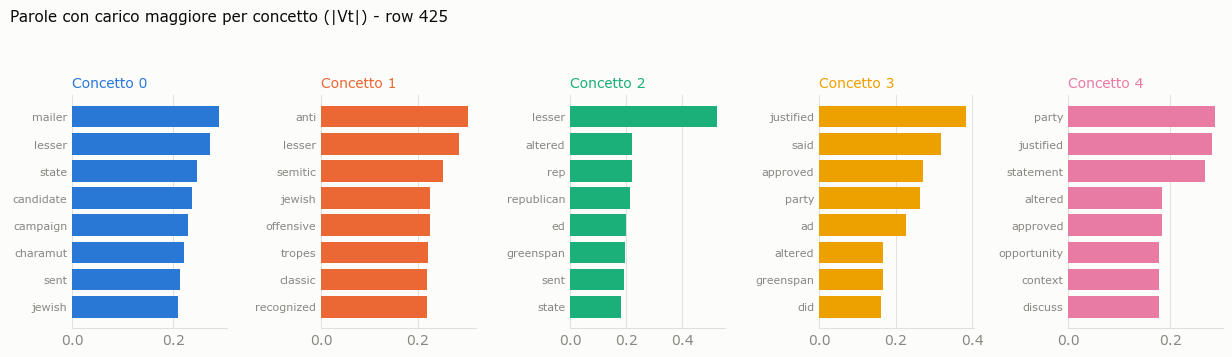

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\heatmap_z_row425.png


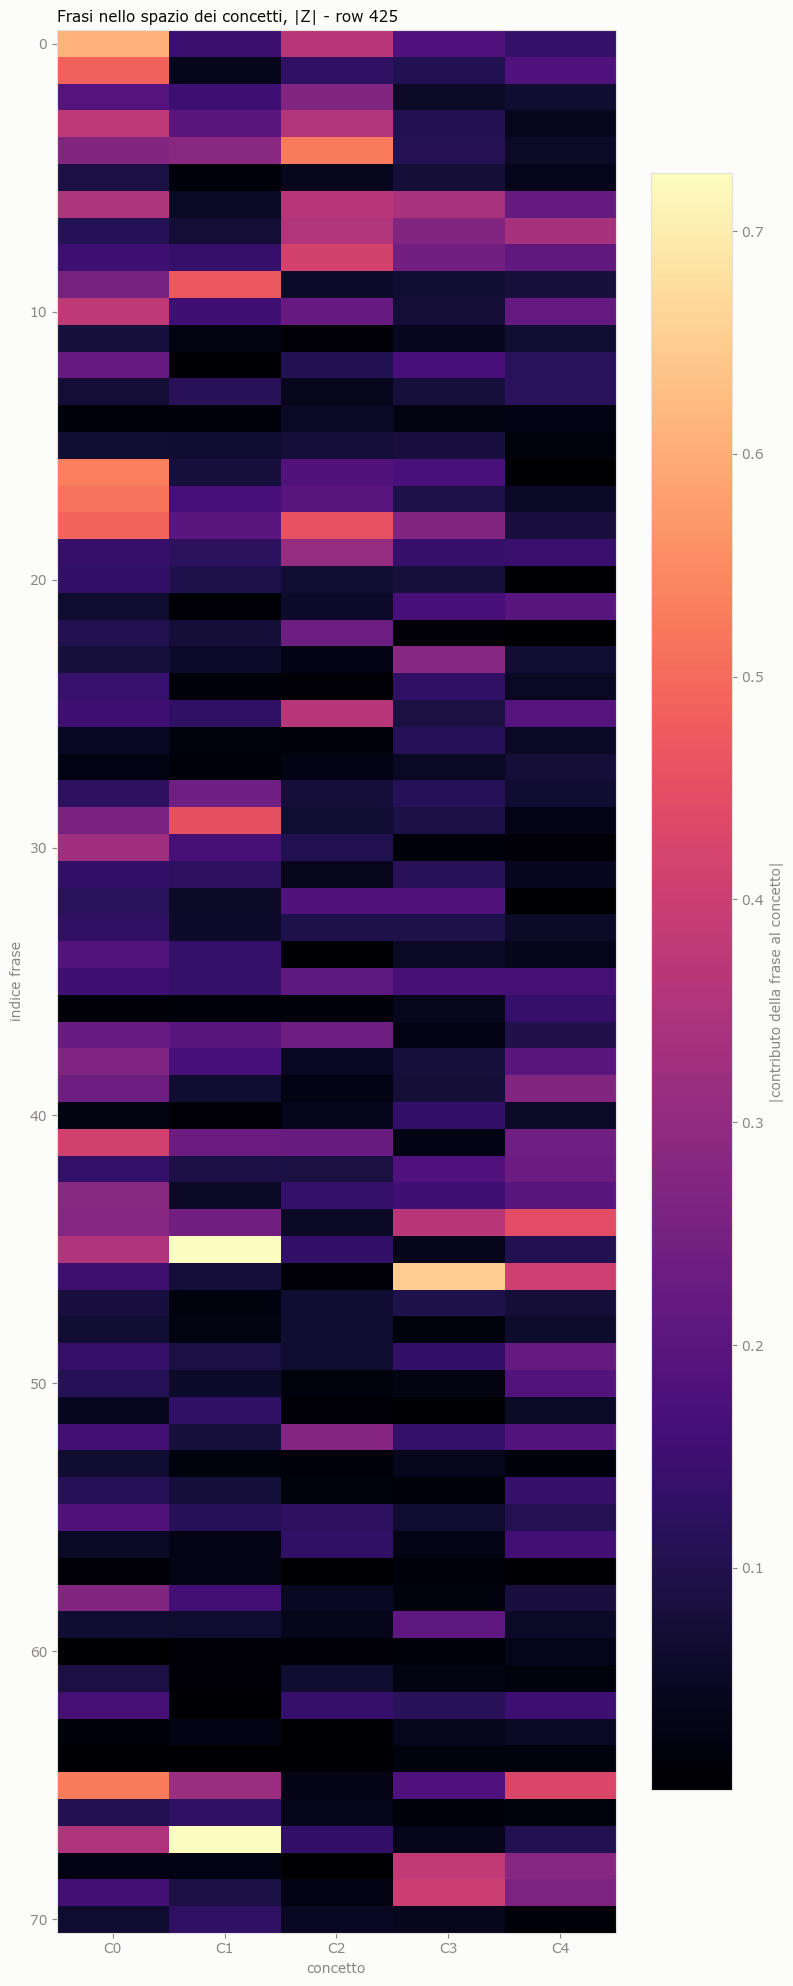

In [6]:
art = analizza_lsa(frasi)
Z, sigma, comp, k = art['Z'], art['sigma'], art['componenti'], art['k']
salienza = art['salienza']
kf = min(N_CONCETTI_FIG, k)          # concetti mostrati nelle figure
print(f'PASSO 3 - SVD troncata a k={k} concetti; matrice Z {Z.shape} (frase x concetto)')
print(f"Varianza spiegata dai {k} concetti tenuti: {art['varianza'].sum():.1%}")
print('Parole con carico maggiore per concetto (|Vt|):')
for c in range(kf):
    parole = [vocab[j] for j in np.argsort(-np.abs(comp[c]))[:N_PAROLE_TOP]]
    print(f"  C{c} (sigma={sigma[c]:.2f}): {', '.join(parole)}")

# --- Figura: scree plot dei valori singolari --------------------------------
fig, ax = plt.subplots(figsize=(6.4, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(k), sigma, color=[col_concetto(c) if c < kf else MUTED for c in range(k)], zorder=2)
ax.set_xticks(range(k))
ax.set_xticklabels([f'C{c}' for c in range(k)], fontsize=8)
ax.set_ylabel('valore singolare sigma')
ax.set_title(f'Energia dei concetti latenti (scree plot) - row {rid}', color=INK, loc='left',
             fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
_salva(fig, f'scree_row{rid}.png')
plt.show()

# --- Figura: parole piu' caratteristiche per concetto (|Vt|) ----------------
fig, axes = plt.subplots(1, kf, figsize=(2.4 * kf + 0.5, 0.30 * N_PAROLE_TOP + 1.2),
                         facecolor=SURFACE)
axes = np.atleast_1d(axes)
for c, ax in enumerate(axes):
    ax.set_facecolor(SURFACE)
    idx = np.argsort(-np.abs(comp[c]))[:N_PAROLE_TOP][::-1]
    ax.barh(range(len(idx)), np.abs(comp[c][idx]), color=col_concetto(c), zorder=2)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([vocab[j] for j in idx], fontsize=8)
    ax.set_title(f'Concetto {c}', color=col_concetto(c), loc='left', fontsize=10)
    ax.grid(axis='x', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
fig.suptitle(f'Parole con carico maggiore per concetto (|Vt|) - row {rid}', color=INK, x=0.01,
             ha='left', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
_salva(fig, f'parole_concetto_row{rid}.png')
plt.show()

# --- Figura: heatmap |Z| (frase x concetto) ---------------------------------
fig, ax = plt.subplots(figsize=(1.1 * kf + 2.5, 0.26 * len(frasi) + 1.5), facecolor=SURFACE)
im = ax.imshow(np.abs(Z[:, :kf]), cmap='magma', aspect='auto')
fig.colorbar(im, ax=ax, shrink=0.85, label='|contributo della frase al concetto|')
ax.set_xticks(range(kf))
ax.set_xticklabels([f'C{c}' for c in range(kf)])
ax.set_title(f'Frasi nello spazio dei concetti, |Z| - row {rid}', color=INK, loc='left',
             fontsize=11)
ax.set_xlabel('concetto')
ax.set_ylabel('indice frase')
plt.tight_layout()
_salva(fig, f'heatmap_z_row{rid}.png')
plt.show()

### Passo 4 — Selezione: top-k contro deflazione (l'anti-ridondanza al lavoro)

La salienza di una frase è la **lunghezza** del suo vettore latente, `‖z‖`. Le due varianti la
usano in modo diverso:

- **`lsa`** prende semplicemente le `N_SENTENCES` più lunghe. Rischio tipico in MDS: le fonti
  raccontano lo stesso fatto, quindi le frasi più salienti sono spesso **doppioni tra loro**.
- **`lsa_steinberger`** ne prende una alla volta e dopo ogni scelta **sottrae** dal residuo la
  direzione appena coperta. La prima figura mostra proprio questo: come cambia la lunghezza
  residua delle frasi dopo le prime scelte — le frasi simili a quella scelta **collassano**.

Le due figure successive confrontano gli esiti: quali frasi entrano in ciascuna variante e
quanto è **ridondante** il set risultante (similarità coseno media tra le coppie selezionate, nello
spazio TF-IDF: più bassa = riassunto meno ripetitivo). La stampa finale elenca le frasi scelte
dalle due varianti, evidenziando quelle su cui **non** sono d'accordo.

PASSO 4 - Selezione
  lsa             : [0, 4, 7, 9, 18, 29, 44, 45, 46, 65, 67]
  lsa_steinberger : [0, 4, 7, 11, 20, 21, 29, 44, 45, 46, 52]
  frasi in comune : 7/11 -> [0, 4, 7, 29, 44, 45, 46]
  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\deflazione_row425.png


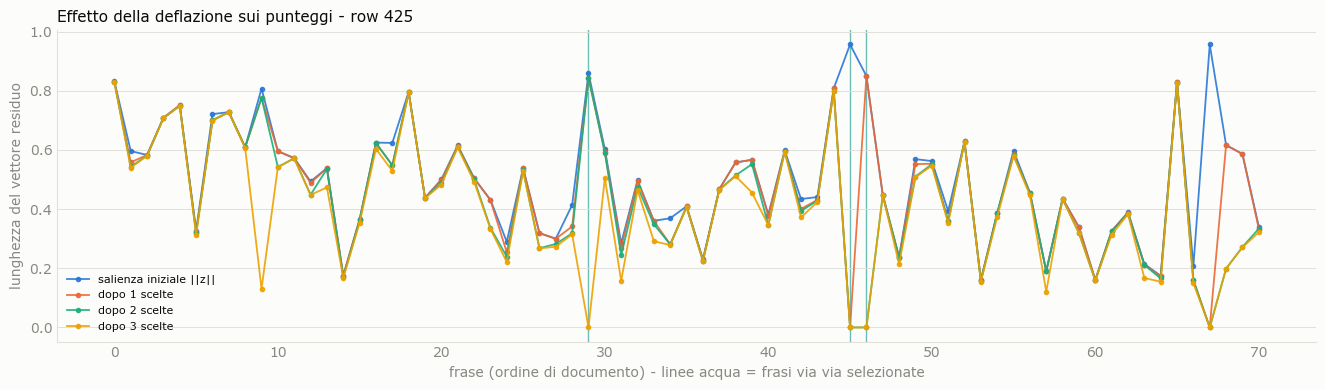

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\salienza_row425.png


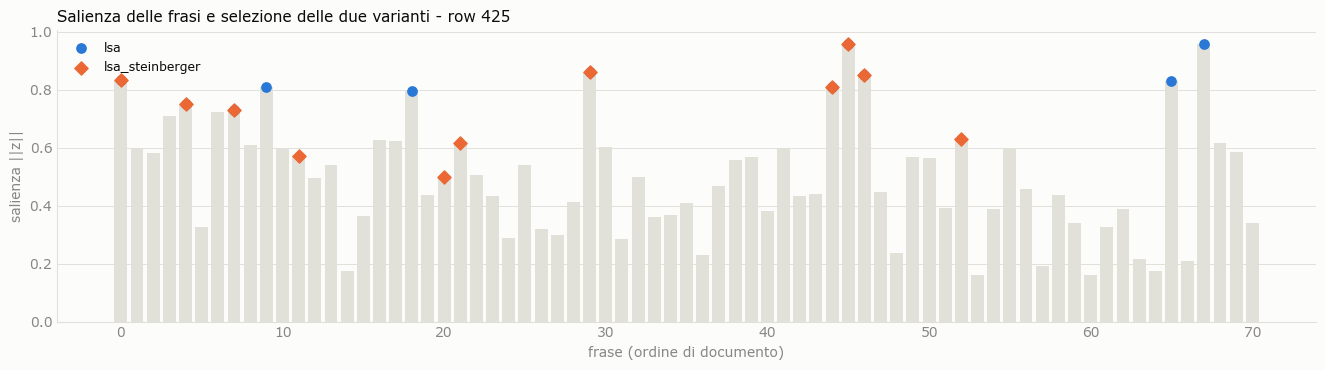

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\lsa\ridondanza_row425.png


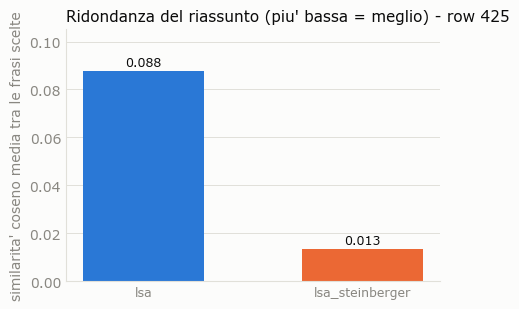


Ridondanza media del set scelto (cosine TF-IDF, piu' bassa = meglio):
  lsa             : 0.088
  lsa_steinberger : 0.013

Frasi selezionate (ordine di documento). [B]=solo lsa, [S]=solo lsa_steinberger, [=]=entrambe
  [=] [ 0] (||z||=0.831) Campaign mailer sent by GOP state Senate candidate Ed Charamut
  [=] [ 4] (||z||=0.751) Lesser
  [=] [ 7] (||z||=0.728) “His eyes were altered to look bigger and greedy,” Greenspan admitted
  [B] [ 9] (||z||=0.807) “The juxtaposition of a Jewish candidate and money in this manner suggests an age-old anti-Semitic trope,” explained Steve Ginsbur
  [S] [11] (||z||=0.572) “If you disagree with a Democrat, this is what they do — they call you racist, sexist or bigot,” claimed GOP Chair JB Romano
  [B] [18] (||z||=0.796) The advertisement, which was sent out by Republican Ed Charamut’s campaign, depicts his challenger, Democratic state Rep
  [S] [20] (||z||=0.500) The mailer drew wide outrage after its existence was reported on Tuesday, as concern about

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

scelti_base = art['scelti'][METODO_BASE]
scelti_stein = art['scelti'][METODO_STEIN]
storia = art['storia']
print('PASSO 4 - Selezione')
print(f'  {METODO_BASE:<16}: {sorted(scelti_base)}')
print(f'  {METODO_STEIN:<16}: {sorted(scelti_stein)}')
comuni = sorted(set(scelti_base) & set(scelti_stein))
print(f'  frasi in comune : {len(comuni)}/{N_SENTENCES} -> {comuni}')

# --- Figura 1: come la deflazione consuma le lunghezze residue --------------
# Ogni curva e' uno "stato" del residuo: prima della 1a scelta (= salienza originale),
# dopo la 1a, dopo la 2a... Le frasi ridondanti rispetto a quelle gia' scelte crollano.
n_passi = min(4, len(storia))
fig, ax = plt.subplots(figsize=(min(0.16 * len(frasi) + 2, 15), 4.0), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for t in range(n_passi):
    ax.plot(storia[t], marker='o', markersize=3, linewidth=1.3,
            color=col_concetto(t), alpha=0.9,
            label='salienza iniziale ||z||' if t == 0 else f'dopo {t} scelte')
for t in range(n_passi - 1):
    ax.axvline(scelti_stein[t], color=ACCENTO, linewidth=1.0, alpha=0.6, zorder=0)
ax.set_xlabel('frase (ordine di documento) - linee acqua = frasi via via selezionate')
ax.set_ylabel('lunghezza del vettore residuo')
ax.set_title(f'Effetto della deflazione sui punteggi - row {rid}', color=INK, loc='left',
             fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
_salva(fig, f'deflazione_row{rid}.png')
plt.show()

# --- Figura 2: salienza per frase e chi viene scelto da chi -----------------
fig, ax = plt.subplots(figsize=(min(0.16 * len(frasi) + 2, 15), 3.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(len(frasi)), salienza, color=GRID, zorder=2)
ax.scatter(scelti_base, salienza[scelti_base] , s=45, color=CONCEPT_COLORS[0], zorder=3,
           label=METODO_BASE)
ax.scatter(scelti_stein, salienza[scelti_stein], s=45, marker='D', color=CONCEPT_COLORS[1],
           zorder=4, label=METODO_STEIN)
ax.set_xlabel('frase (ordine di documento)')
ax.set_ylabel('salienza ||z||')
ax.set_title(f'Salienza delle frasi e selezione delle due varianti - row {rid}', color=INK,
             loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
_salva(fig, f'salienza_row{rid}.png')
plt.show()

# --- Ridondanza del set selezionato: lsa vs lsa_steinberger -----------------
sim = cosine_similarity(A)          # similarita' lessicale tra le frasi (spazio TF-IDF)


def ridondanza_media(indici):
    """Similarita' coseno media tra le coppie del set selezionato (0 se <2 frasi)."""
    coppie = [sim[a][b] for i, a in enumerate(indici) for b in indici[i + 1:]]
    return float(np.mean(coppie)) if coppie else 0.0


valori = [ridondanza_media(scelti_base), ridondanza_media(scelti_stein)]
fig, ax = plt.subplots(figsize=(4.6, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar([0, 1], valori, color=[CONCEPT_COLORS[0], CONCEPT_COLORS[1]], width=0.55, zorder=2)
for i, v in enumerate(valori):
    ax.annotate(f'{v:.3f}', (i, v), xytext=(0, 4), textcoords='offset points', ha='center',
                fontsize=9, color=INK)
ax.set_xticks([0, 1])
ax.set_xticklabels([METODO_BASE, METODO_STEIN], fontsize=9)
ax.set_ylabel('similarita\' coseno media tra le frasi scelte')
ax.set_title(f'Ridondanza del riassunto (piu\' bassa = meglio) - row {rid}', color=INK,
             loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.margins(y=0.2)
plt.tight_layout()
_salva(fig, f'ridondanza_row{rid}.png')
plt.show()

print()
print(f'Ridondanza media del set scelto (cosine TF-IDF, piu\' bassa = meglio):')
print(f'  {METODO_BASE:<16}: {valori[0]:.3f}')
print(f'  {METODO_STEIN:<16}: {valori[1]:.3f}')
print()
print('Frasi selezionate (ordine di documento). [B]=solo lsa, [S]=solo lsa_steinberger, '
      '[=]=entrambe')
for i in sorted(set(scelti_base) | set(scelti_stein)):
    tag = '=' if i in comuni else ('B' if i in scelti_base else 'S')
    print(f'  [{tag}] [{i:>2}] (||z||={salienza[i]:.3f}) {frasi[i][:130]}')

## Valutazione (indipendente dalla generazione)

Legge **solo** i file salvati; rieseguibile senza rigenerare i riassunti. Metriche ROUGE-1/2/L
(F1, precisione, recall), BLEU e METEOR con la normalizzazione identica a tutti i metodi del
benchmark. Output, per ciascuna variante: `results/metrics/{metodo}_{scope}_per_example.csv` e
`…_aggregate.json`.

In [8]:
import json

aggregati = {}
for metodo in METODI:
    riassunti = su.carica_riassunti(P['summaries_dir'] / f'{metodo}_{SCOPE}.tsv')
    config = {'k_latente': K_LATENTE, 'n_sentences': N_SENTENCES,
              'segmentazione': 'psr.summarization',
              'vettorizzazione': 'sklearn TfidfVectorizer (stop_words=english)',
              'modello': 'sklearn TruncatedSVD (LSA)',
              'selezione': ('top-k per norma latente (Gong & Liu, come sumy)'
                            if metodo == METODO_BASE else
                            'greedy con deflazione della matrice residua (Steinberger, MDS)'),
              'libreria_valutazione': 'pyAutoSummarizer 1.2.0'}
    print(f'== {metodo} ==')
    _, aggregati[metodo] = su.valuta_e_salva(esempi_scope(), riassunti, metodo, SCOPE,
                                             P['metrics_dir'], config)
    print()

print('Medie complessive (confronto tra le due varianti):')
for metodo, agg in aggregati.items():
    o = agg['overall']
    print(f"  {metodo:<16} n={agg['n_esempi']:<6} "
          f"R1={o.get('rouge1_f1', 0):.4f}  R2={o.get('rouge2_f1', 0):.4f}  "
          f"RL={o.get('rougeL_f1', 0):.4f}  BLEU={o.get('bleu', 0):.4f}")
print()
print(json.dumps({m: a['overall'] for m, a in aggregati.items()}, indent=2))

== lsa ==


Metriche per-esempio : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lsa_test_per_example.csv (5588 righe)
Metriche aggregate   : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lsa_test_aggregate.json

== lsa_steinberger ==


Metriche per-esempio : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lsa_steinberger_test_per_example.csv (5588 righe)
Metriche aggregate   : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\lsa_steinberger_test_aggregate.json

Medie complessive (confronto tra le due varianti):
  lsa              n=5588   R1=0.3512  R2=0.1272  RL=0.1833  BLEU=0.0910
  lsa_steinberger  n=5588   R1=0.3757  R2=0.1374  RL=0.1883  BLEU=0.1028

{
  "lsa": {
    "rouge1_f1": 0.35120333112982766,
    "rouge1_p": 0.3839934373729118,
    "rouge1_r": 0.35662404281553073,
    "rouge2_f1": 0.12722237065864744,
    "rouge2_p": 0.13640278062273362,
    "rouge2_r": 0.1352111378228191,
    "rougeL_f1": 0.18330694998236455,
    "rougeL_p": 0.17927975463819126,
    "rougeL_r": 0.2098001774581518,
    "bleu": 0.0909587453393057,
    "meteor": 0.4002680967425159,
    "parole_generate": 248.57605583392984
  },
  "lsa_steinberger": {
    "rouge1_f1": 0.3757272425034112,
    "rouge1_p": 0.357829

## Ispezione qualitativa

Qualche esempio con **entrambe** le varianti affiancate: è il modo più diretto per vedere se la
deflazione sta davvero eliminando i doppioni tra le fonti o se sta solo sostituendo frasi salienti
con frasi marginali.

In [9]:
# --- Ispezione qualitativa --------------------------------------------------
# Sugli ambiti grandi (test/full) il default e' 3 esempi: con None il notebook
# eseguito conterrebbe migliaia di documenti interi.
N_ISPEZIONE      = None if SCOPE == 'sample' else 3   # un intero oppure None = tutti
MOSTRA_DOCUMENTO = True   # False per nascondere gli articoli sorgente (output piu' corto)

riassunti = {m: su.carica_riassunti(P['summaries_dir'] / f'{m}_{SCOPE}.tsv') for m in METODI}

mostrati = 0
for rif in esempi_scope():
    rid = rif['row_id']
    if not all(rid in riassunti[m] for m in METODI):
        continue
    if N_ISPEZIONE is not None and mostrati >= N_ISPEZIONE:
        break
    print('=' * 100)
    print(f"row_id={rid} | split={rif['split']}")
    if MOSTRA_DOCUMENTO:
        articoli = [a.strip() for a in rif['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
        print()
        print(f'----- DOCUMENTO ({len(articoli)} articoli) -----')
        for i, art_txt in enumerate(articoli, 1):
            print(f'[articolo {i}]')
            print(art_txt)
            print()
    print('----- RIFERIMENTO -----')
    print(su.pulisci_riferimento(rif['summary']))
    for m in METODI:
        print()
        print(f'----- GENERATO [{m}] -----')
        print(riassunti[m][rid])
    print()
    mostrati += 1
print()
print(f'({mostrati} esempi mostrati)')

row_id=50491 | split=test

----- DOCUMENTO (2 articoli) -----
[articolo 1]
GOP Eyes Gains As Voters In 11 States Pick Governors 
 
 Enlarge this image toggle caption Jim Cole/AP Jim Cole/AP 
 
 Voters in 11 states will pick their governors tonight, and Republicans appear on track to increase their numbers by at least one, with the potential to extend their hold to more than two-thirds of the nation's top state offices. 
 
 Eight of the gubernatorial seats up for grabs are now held by Democrats; three are in Republican hands. Republicans currently hold 29 governorships, Democrats have 20, and Rhode Island's Gov. Lincoln Chafee is an Independent. 
 
 Polls and race analysts suggest that only three of tonight's contests are considered competitive, all in states where incumbent Democratic governors aren't running again: Montana, New Hampshire and Washington. 
 
 While those state races remain too close to call, Republicans are expected to wrest the North Carolina governorship from Democrat